# GUÍA DE NOTACIÓN MATEMÁTICA POR MÉTODO

## MÉTODOS DE BÚSQUEDA DE RAÍCES (f(x) = 0):
---

1. BISECCIÓN
   - Intervalo: [xl, xu] con f(xl)·f(xu) < 0
   - Punto medio: xr = (xl + xu)/2
   - Error: |xu - xl| (el intervalo se reduce a la mitad)
   - Columnas: x0=xl, x1=xu, x2=xr

2. FALSA POSICIÓN
   - Intervalo: [xl, xu] con f(xl)·f(xu) < 0
   - Interpolación: xr = xu - f(xu)·(xl-xu)/(f(xl)-f(xu))
   - Error: |xr - xr_old| (no reduce uniformemente)
   - Columnas: x0=xl, x1=xu, x2=xr

3. NEWTON-RAPHSON
   - Iteración: x_{n+1} = x_n - f(x_n)/f'(x_n)
   - Error: |x_{n+1} - x_n| (convergencia cuadrática)
   - Columnas: x0=x_n, x1=x_{n+1}

## MÉTODOS DE OPTIMIZACIÓN 1D (f'(x) = 0):
---

4. RAZÓN DORADA
   - Razón: φ = (√5-1)/2 ≈ 0.618
   - Puntos interiores: x1 = xl + (1-φ)(xu-xl), x2 = xu - φ(xu-xl)
   - Error: xu - xl (se reduce por factor φ)
   - Columnas: xl, xu, x1, x2 (puntos interiores)

5. INTERPOLACIÓN CUADRÁTICA
   - Ajuste: parábola por 3 puntos (x0, x1, x2)
   - Nuevo punto: x3 = vértice de la parábola
   - Error: |x3 - x3_old| (convergencia superlineal)
   - Columnas: x0, x1, x2 (puntos), x3 (nuevo)

6. NEWTON OPTIMIZACIÓN
   - Iteración: x_{n+1} = x_n - f'(x_n)/f''(x_n)
   - Error: |x_{n+1} - x_n| (convergencia cuadrática)
   - Columnas: x0=x_n, x1=x_{n+1}

## MÉTODOS ESTOCÁSTICOS:
---

7. BÚSQUEDA ALEATORIA
   - Muestreo uniforme en [min, max]^n
   - Error: |mejor_f - mejor_f_anterior|
   - Columnas: x0, x1, ..., xn (punto muestreado)
              mejor_x0, mejor_x1, ... (mejor punto)


In [1]:
import math
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from IPython.display import display

def graficar(metodo, f, rango_x, df_iter, result_x, optimizacion=False):
    """Gráfica genérica para métodos de una sola variable (raíces u optimización 1D)."""
    plt.figure(figsize=(12, 5))

    # Panel 1: Error por iteración (común a todos los métodos)
    plt.subplot(1, 2, 1)
    plt.plot(df_iter['Iteracion'], df_iter['Error'], marker='o', linestyle='-', color='blue')
    plt.title(f'{metodo} - Error por Iteración')
    plt.xlabel('Iteración')
    plt.ylabel('Error')
    plt.grid(True, alpha=0.4)

    # Panel 2: Función y resultado
    plt.subplot(1, 2, 2)
    x_vals = np.linspace(rango_x[0], rango_x[1], 400)
    y_vals = f(x_vals)
    plt.plot(x_vals, y_vals, label='f(x)', color='purple')
    
    if optimizacion:
        plt.axhline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
        etiqueta = "Óptimo"
    else:
        plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
        etiqueta = "Raíz"
    
    plt.axvline(result_x, color="red", linestyle=':', label=f'{etiqueta} x={result_x:.4f}')
    plt.scatter(result_x, f(result_x), color='red', marker='o', s=50, zorder=5)
    
    plt.title(f'{metodo} - Función y {etiqueta}')
    plt.xlabel('x')
    plt.ylabel('f(x)')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Bisección

In [2]:
def biseccion(f, xl, xu, error, max_iter=200):
    """
    Método de bisección para encontrar una raíz de f en [xl, xu].

    Requiere que f(xl) y f(xu) tengan signos opuestos (Teorema de Bolzano).
    """
    if xl >= xu:
        raise ValueError("Se requiere xl < xu")

    fxl, fxu = f(xl), f(xu)
    if fxl * fxu > 0:
        raise ValueError(
            "f(xl) y f(xu) deben tener signos opuestos: no hay garantía de raíz en el intervalo"
        )

    iter_data = []
    xr = (xl + xu) / 2
    iteraciones = 0

    while abs(xu - xl) > error and iteraciones < max_iter:
        xr = (xl + xu) / 2
        fxr = f(xr)
        current_error = abs(xu - xl)

        iter_data.append({
            "Iteracion": iteraciones + 1,
            "x0": xl, "f(x0)": fxl,
            "x1": xu, "f(x1)": fxu,
            "x2": xr, "f(x2)": fxr,
            "Error": current_error
        })

        if fxr == 0:
            break
        elif fxl * fxr < 0:      # CORRECCIÓN: comparar contra fxl (cacheado), no volver a llamar f()
            xu, fxu = xr, fxr
        else:
            xl, fxl = xr, fxr
        iteraciones += 1

    return xr, pd.DataFrame(iter_data)

Raíz encontrada: 39.1485


,Iteracion,x0,f(x0),x1,f(x1),x2,f(x2),Error
0,1,38.000000,-128.000000,40.000000,100.000000,39.000000,-17.000000,2.000000
1,2,39.000000,-17.000000,40.000000,100.000000,39.500000,40.750000,1.000000
2,3,39.000000,-17.000000,39.500000,40.750000,39.250000,11.687500,0.500000
3,4,39.000000,-17.000000,39.250000,11.687500,39.125000,-2.703125,0.250000
4,5,39.125000,-2.703125,39.250000,11.687500,39.187500,4.480469,0.125000
5,6,39.125000,-2.703125,39.187500,4.480469,39.156250,0.885742,0.062500
6,7,39.125000,-2.703125,39.156250,0.885742,39.140625,-0.909424,0.031250
7,8,39.140625,-0.909424,39.156250,0.885742,39.148438,-0.012024,0.015625
8,9,39.148438,-0.012024,39.156250,0.885742,39.152344,0.436813,0.007812
9,10,39.148438,-0.012024,39.152344,0.436813,39.150391,0.212383,0.003906


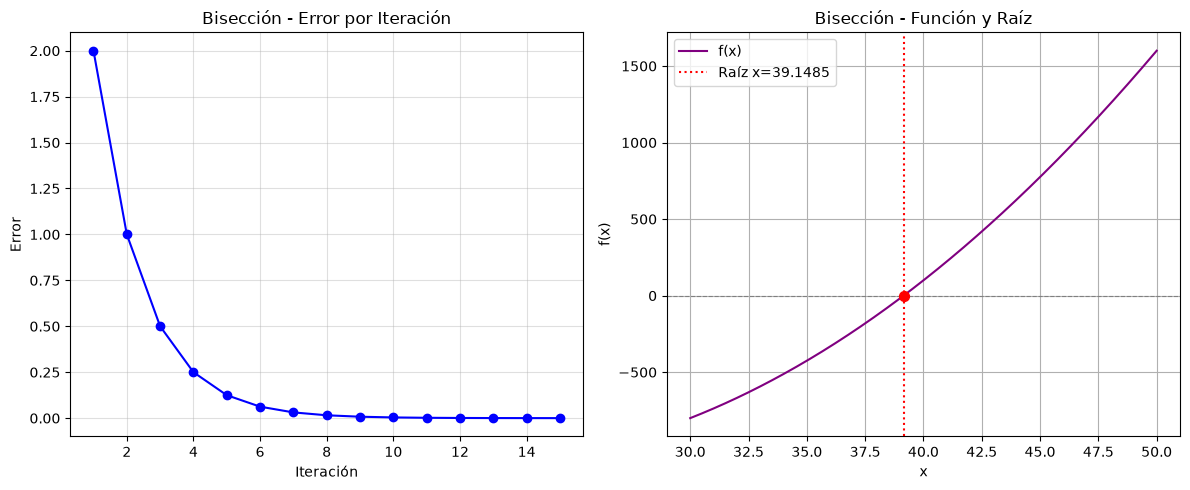

In [3]:
def f_bis(x): return 3*x**2 - 120*x + 100

raiz, df_bis = biseccion(f_bis, 38, 40, 0.0001)
print(f'Raíz encontrada: {raiz:.4f}')
display(df_bis)
graficar('Bisección', f_bis, (30, 50), df_bis, raiz)

# Falsa Posición

In [4]:
def falsa_posicion(f, xl, xu, error, max_iter=200, illinois=True):
    """
    Método de falsa posición (regula falsi) con modificación de Illinois opcional.

    La modificación de Illinois evita el estancamiento clásico de regula falsi
    (cuando un extremo del intervalo queda fijo durante muchas iteraciones y la
    convergencia se vuelve lineal lenta): si un mismo lado se repite dos veces
    seguidas, se atenúa a la mitad el valor de f en el extremo fijo.
    """
    if xl >= xu:
        raise ValueError("Se requiere xl < xu")

    fxl, fxu = f(xl), f(xu)
    if fxl * fxu > 0:
        raise ValueError("f(xl) y f(xu) deben tener signos opuestos")

    iter_data = []
    xr_old = xl
    lado_repetido = 0
    iteraciones = 0

    while iteraciones < max_iter:
        denom = fxl - fxu
        if denom == 0:
            raise ZeroDivisionError("f(xl) == f(xu): la fórmula de falsa posición no está definida")

        xr = xu - (fxu * (xl - xu)) / denom
        fxr = f(xr)
        current_error = abs(xr - xr_old)

        iter_data.append({
            "Iteracion": iteraciones + 1,
            "x0": xl, "f(x0)": fxl,
            "x1": xu, "f(x1)": fxu,
            "x2": xr, "f(x2)": fxr,
            "Error": current_error
        })

        if abs(fxr) < 1e-12 or current_error < error:
            break

        if fxl * fxr < 0:
            xu, fxu = xr, fxr
            lado_repetido = lado_repetido + 1 if lado_repetido >= 0 else 1
            if illinois and lado_repetido >= 2:
                fxl /= 2
        else:
            xl, fxl = xr, fxr
            lado_repetido = lado_repetido - 1 if lado_repetido <= 0 else -1
            if illinois and lado_repetido <= -2:
                fxu /= 2

        xr_old = xr
        iteraciones += 1

    return xr, pd.DataFrame(iter_data)

Raíz encontrada: 39.1485


,Iteracion,x0,f(x0),x1,f(x1),x2,f(x2),Error
0,1,38.000000,-1.280000e+02,40.000000,100.00000,39.122807,-2.954755e+00,1.122807e+00
1,2,39.122807,-2.954755e+00,40.000000,100.00000,39.147982,-6.434877e-02,2.517505e-02
2,3,39.147982,-6.434877e-02,40.000000,50.00000,39.149077,6.147048e-02,1.095117e-03
3,4,39.147982,-6.434877e-02,39.149077,0.06147,39.148542,-8.989900e-07,5.350322e-04
4,5,39.148542,-8.989900e-07,39.149077,0.06147,39.148542,-1.273293e-11,7.824596e-09


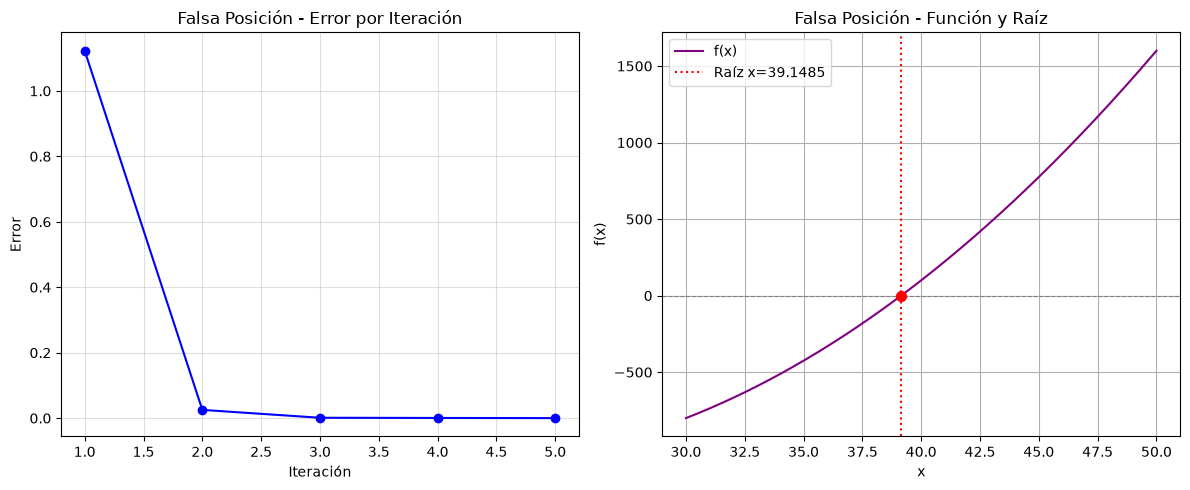

In [5]:
def f_fp(x): return 3*x**2 - 120*x + 100

raiz, df_fp = falsa_posicion(f_fp, 38, 40, 0.0001)
print(f"Raíz encontrada: {raiz:.4f}")
display(df_fp)
graficar("Falsa Posición", f_fp, (30, 50), df_fp, raiz)

# Razón Dorada

In [6]:
def razon_dorada(f, xl, xu, error, modo="max", max_iter=200):
    """
    Encuentra el óptimo (máximo o mínimo) de una función unimodal f en [xl, xu]
    usando el método de la sección/razón dorada.
    """
    if xl >= xu:
        raise ValueError("Se requiere xl < xu")
    if modo not in ("max", "min"):
        raise ValueError("El parámetro 'modo' debe ser 'max' o 'min'")

    phi = (1 + math.sqrt(5)) / 2
    R = phi - 1  # Aproximadamente 0.61803

    iteraciones = 0
    iter_data = []

    d = R * (xu - xl)
    x1 = xl + d
    x2 = xu - d
    f1 = f(x1)
    f2 = f(x2)

    while (xu - xl) > error and iteraciones < max_iter:
        current_error = xu - xl

        iter_data.append({
            "Iteracion": iteraciones + 1,
            "xl": xl, "f(xl)": f(xl),
            "xu": xu, "f(xu)": f(xu),
            "x1": x1, "f(x1)": f1,
            "x2": x2, "f(x2)": f2,  
            "Error": current_error
        })

        cambiar_limite_derecho = f2 > f1 if modo == "max" else f2 < f1

        if cambiar_limite_derecho:
            xu = x1
            x1 = x2
            f1 = f2
            d = R * (xu - xl)
            x2 = xu - d
            f2 = f(x2)
        else:
            xl = x2
            x2 = x1
            f2 = f1
            d = R * (xu - xl)
            x1 = xl + d
            f1 = f(x1)

        iteraciones += 1

    x_opt = (xl + xu) / 2
    return x_opt, pd.DataFrame(iter_data)

Óptimo encontrado: 3.0000


,Iteracion,xl,f(xl),xu,f(xu),x1,f(x1),x2,f(x2),Error
0,1,0.000000,1.000000,5.000000,6.000000,3.090170,9.991869,1.909830,8.811529,5.000000
1,2,1.909830,8.811529,5.000000,6.000000,3.819660,9.328157,3.090170,9.991869,3.090170
2,3,1.909830,8.811529,3.819660,9.328157,3.090170,9.991869,2.639320,9.869910,1.909830
3,4,2.639320,9.869910,3.819660,9.328157,3.368810,9.863979,3.090170,9.991869,1.180340
4,5,2.639320,9.869910,3.368810,9.863979,3.090170,9.991869,2.917961,9.993270,0.729490
5,6,2.639320,9.869910,3.090170,9.991869,2.917961,9.993270,2.811529,9.964479,0.450850
6,7,2.811529,9.964479,3.090170,9.991869,2.983739,9.999736,2.917961,9.993270,0.278640
7,8,2.917961,9.993270,3.090170,9.991869,3.024392,9.999405,2.983739,9.999736,0.172209
8,9,2.917961,9.993270,3.024392,9.999405,2.983739,9.999736,2.958614,9.998287,0.106431
9,10,2.958614,9.998287,3.024392,9.999405,2.999267,9.999999,2.983739,9.999736,0.065778


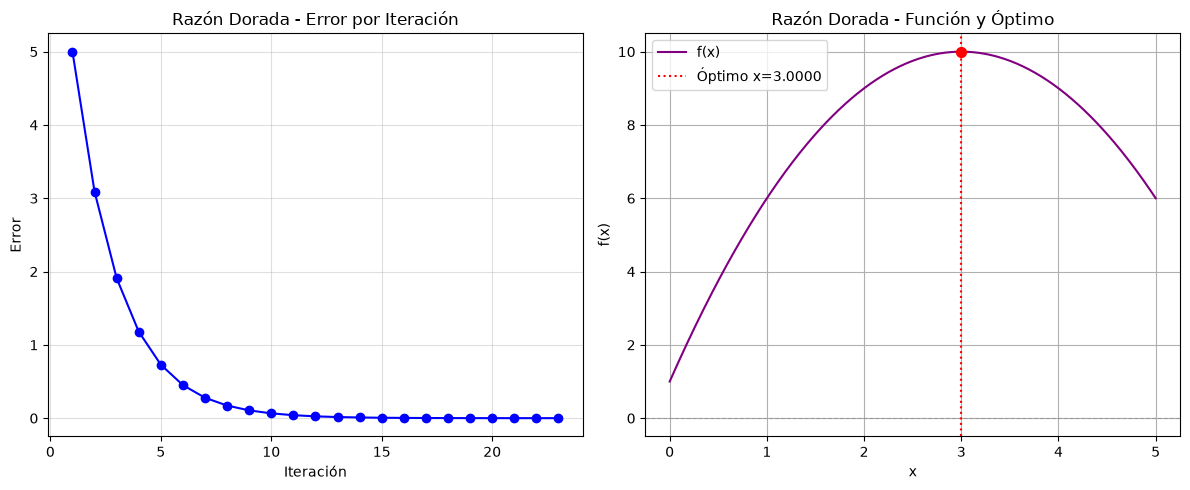

In [7]:
def f_rd(x): return -(x-3)**2 + 10

optimo, df_rd = razon_dorada(f_rd, 0, 5, 0.0001, modo="max")
print(f"Óptimo encontrado: {optimo:.4f}")
display(df_rd)
graficar("Razón Dorada", f_rd, (0, 5), df_rd, optimo, optimizacion=True)

# Interpolación

In [8]:
def interpolacion(f, x0, x1, x2, error, modo="max", max_iter=200, tol_den=1e-14):
    """
    Encuentra el óptimo (máximo o mínimo) de f usando interpolación cuadrática
    (ajuste de una parábola a tres puntos x0, x1, x2).
    """
    if modo not in ("max", "min"):
        raise ValueError("El parámetro 'modo' debe ser 'max' o 'min'")

    iter_data = []
    x3_old = None
    iteraciones = 0
    x3 = None

    while iteraciones < max_iter:
        f0, f1, f2 = f(x0), f(x1), f(x2)

        den = 2*f0*(x1 - x2) + 2*f1*(x2 - x0) + 2*f2*(x0 - x1)
        if abs(den) < tol_den:
            raise ZeroDivisionError(
                "Los tres puntos son (casi) colineales: la parábola no está bien determinada; "
                "elija otros puntos iniciales"
            )
        num = f0*(x1**2 - x2**2) + f1*(x2**2 - x0**2) + f2*(x0**2 - x1**2)
        x3 = num / den
        f3 = f(x3)

        current_error = abs(x3 - x3_old) if x3_old is not None else abs(x2 - x0)

        iter_data.append({
            "Iteracion": iteraciones + 1,
            "x0": x0, "f(x0)": f0,
            "x1": x1, "f(x1)": f1,
            "x2": x2, "f(x2)": f2,
            "x3": x3, "f(x3)": f3,
            "Error": current_error
        })

        if current_error < error:
            break

        mejora = f3 > f1 if modo == "max" else f3 < f1

        if mejora:
            if x3 > x1: x0 = x1
            else: x2 = x1
        else:
            if x3 > x1: x2 = x3
            else: x0 = x3

        x1 = x3
        x3_old = x3
        iteraciones += 1

    return x3, pd.DataFrame(iter_data)

Óptimo encontrado: 1.4276


,Iteracion,x0,f(x0),x1,f(x1),x2,f(x2),x3,f(x3),Error
0,1,0.000000,0.000000,1.000000,1.582942,4.000000,-3.113605,1.505535,1.769079,4.000000
1,2,1.000000,1.582942,1.505535,1.769079,4.000000,-3.113605,1.490253,1.771431,0.015282
2,3,1.000000,1.582942,1.490253,1.771431,1.505535,1.769079,1.425636,1.775722,0.064617
3,4,1.000000,1.582942,1.425636,1.775722,1.490253,1.771431,1.426602,1.775725,0.000966
4,5,1.425636,1.775722,1.426602,1.775725,1.490253,1.771431,1.427548,1.775726,0.000947
5,6,1.426602,1.775725,1.427548,1.775726,1.490253,1.771431,1.427551,1.775726,0.000002


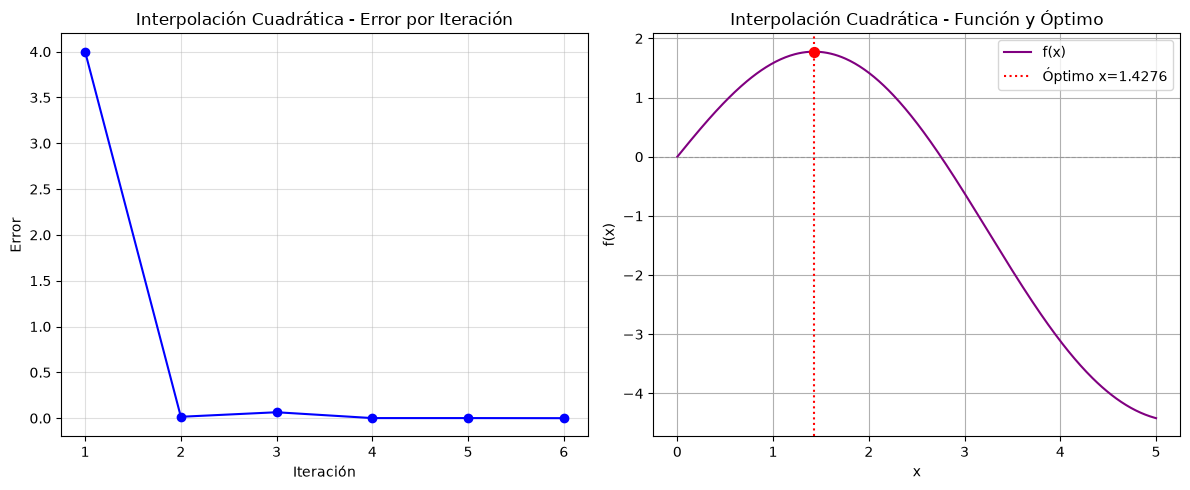

In [9]:
def f_ic(x): return 2*np.sin(x) - (x**2)/10

optimo, df_ic = interpolacion(f_ic, 0, 1, 4, 0.0001, modo="max")
print(f"Óptimo encontrado: {optimo:.4f}")
display(df_ic)
graficar("Interpolación Cuadrática", f_ic, (0, 5), df_ic, optimo, optimizacion=True)

# Newton-Raphson

In [10]:
def newton_raphson(f, df, x0, error, max_iter=100, tol_derivada=1e-14):
    """Método de Newton-Raphson para encontrar una raíz de f, dada su derivada df."""
    iteraciones = 0
    iter_data = []
    xi = x0

    while True:
        dfx = df(xi)
        if abs(dfx) < tol_derivada:
            raise ZeroDivisionError(f"df(x) ≈ 0 en x={xi}: el método diverge o se estanca")

        x_next = xi - f(xi) / dfx
        current_error = abs(x_next - xi)

        iter_data.append({
            "Iteracion": iteraciones + 1,
            "x0": xi, "f(x0)": f(xi),
            "x1": x_next, "f(x1)": f(x_next),
            "Error": current_error
        })

        xi = x_next
        iteraciones += 1
        if current_error < error or iteraciones >= max_iter:
            break

    return xi, pd.DataFrame(iter_data)

Raíz encontrada: 39.1485


,Iteracion,x0,f(x0),x1,f(x1),Error
0,1,38.000000,-128.000000,39.185185,4.213992e+00,1.185185
1,2,39.185185,4.213992,39.148577,4.020445e-03,0.036608
2,3,39.148577,0.004020,39.148542,3.674359e-09,0.000035


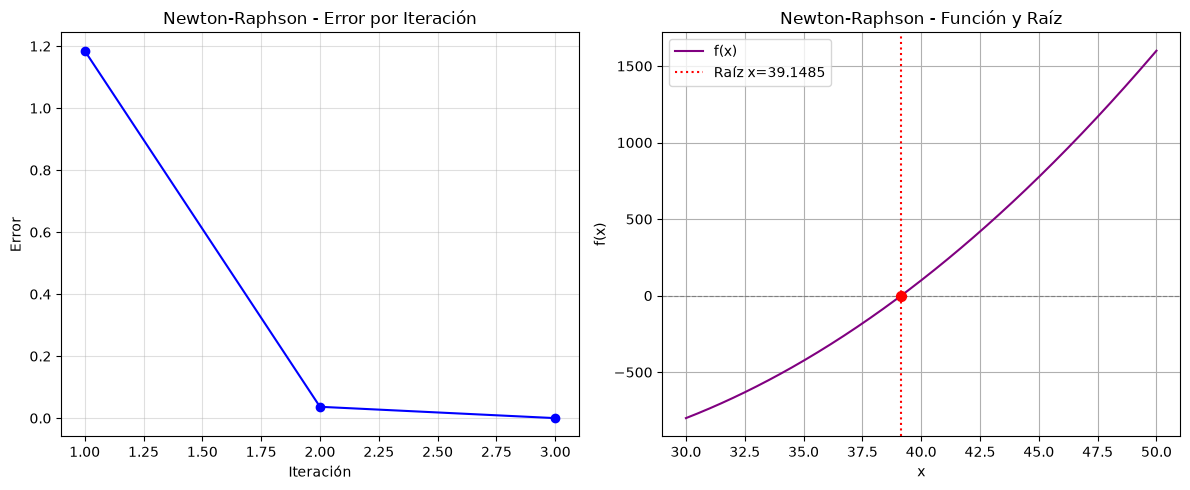

In [11]:
def f_nr(x): return 3*x**2 - 120*x + 100
def df_nr(x): return 6*x - 120

raiz, df_nr_res = newton_raphson(f_nr, df_nr, 38, 0.0001)
print(f"Raíz encontrada: {raiz:.4f}")
display(df_nr_res)
graficar("Newton-Raphson", f_nr, (30, 50), df_nr_res, raiz)

# Newton (optimización)

In [ ]:
def newton_optimizacion(f, df, ddf, x0, error, max_iter=100, tol_segunda_derivada=1e-14):
    """Método de Newton para optimización 1D (busca donde df(x)=0 usando la segunda derivada)."""
    iteraciones = 0
    iter_data = []
    xi = x0

    while True:
        ddfx = ddf(xi)
        if abs(ddfx) < tol_segunda_derivada:
            raise ZeroDivisionError(f"f''(x) ≈ 0 en x={xi}: el método diverge o se estanca")

        x_next = xi - df(xi) / ddfx
        current_error = abs(x_next - xi)

        iter_data.append({
            "Iteracion": iteraciones + 1,
            "x0": xi, "f(x0)": f(xi),
            "x1": x_next, "f(x1)": f(x_next),
            "Error": current_error
        })

        xi = x_next
        iteraciones += 1
        if current_error < error or iteraciones >= max_iter:
            break

    return xi, pd.DataFrame(iter_data)

Óptimo encontrado: 1.4276


,Iteracion,x0,f(x0),x1,f(x1),Error
0,1,2.500000,0.571944,0.995082,1.578588,1.504918
1,2,0.995082,1.578588,1.469011,1.773849,0.473929
2,3,1.469011,1.773849,1.427642,1.775726,0.041368
3,4,1.427642,1.775726,1.427552,1.775726,0.000091


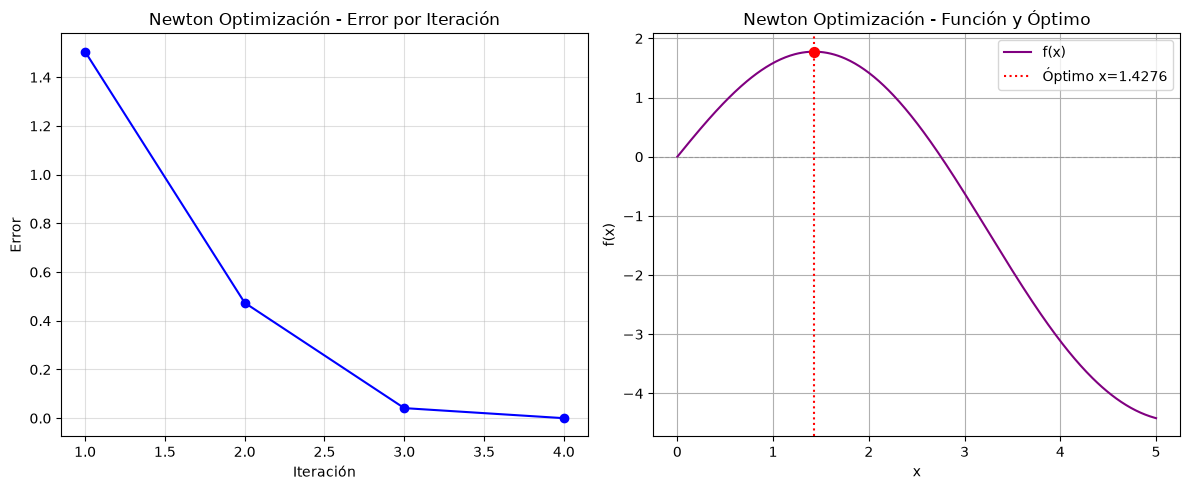

In [13]:
def f_no(x): return 2*np.sin(x) - (x**2)/10
def df_no(x): return 2*np.cos(x) - x/5
def ddf_no(x): return -2*np.sin(x) - 1/5

optimo, df_no_res = newton_optimizacion(f_no, df_no, ddf_no, 2.5, 0.0001)
print(f"Óptimo encontrado: {optimo:.4f}")
display(df_no_res)
graficar("Newton Optimización", f_no, (0, 5), df_no_res, optimo, optimizacion=True)

# Búsqueda Aleatoria

**Reescritura completa.** La versión original tenía tres problemas serios:

1. Mezclaba dos generadores de números aleatorios (`random` y `np.random`) usando solo uno de ellos.
2. Guardaba el punto muestreado y el "mejor punto hasta ahora" en las mismas columnas (`x0`..`x3`)
   que en los demás métodos usan un significado distinto, lo cual es confuso y solo funciona para 2 variables.
3. **No generaba ninguna gráfica**, a pesar de que un método estocástico se entiende mucho mejor
   viendo (a) la curva de convergencia del mejor valor y (b) el patrón de exploración del espacio de búsqueda.

La nueva versión generaliza a *n* variables, vectoriza el muestreo con NumPy, admite `modo="max"/"min"` y usa nombres de columna explícitos.

In [14]:
def busqueda_aleatoria(f, rangos, n_iteraciones, semilla=42, modo="max"):
    """
    Búsqueda aleatoria (pura) para optimización de una función de n variables.

    Args:
        f: función objetivo, recibe n_variables argumentos escalares f(x0, x1, ..., xn-1)
        rangos: lista de tuplas [(min_0, max_0), (min_1, max_1), ...], una por variable
        n_iteraciones: número de puntos aleatorios a muestrear
        semilla: semilla para reproducibilidad
        modo: "max" o "min"

    Returns:
        mejor_punto (np.ndarray), mejor_valor (float), DataFrame con el historial de iteraciones
    """
    if modo not in ("max", "min"):
        raise ValueError("El parámetro 'modo' debe ser 'max' o 'min'")
    for lo, hi in rangos:
        if lo >= hi:
            raise ValueError(f"Rango inválido {(lo, hi)}: el mínimo debe ser menor que el máximo")
    if n_iteraciones < 1:
        raise ValueError("n_iteraciones debe ser >= 1")

    rng = np.random.default_rng(semilla)
    n_variables = len(rangos)
    lo = np.array([r[0] for r in rangos])
    hi = np.array([r[1] for r in rangos])

    # Muestreo vectorizado: todos los puntos aleatorios de una sola vez
    # (más eficiente que un bucle en Python llamando random.random() variable por variable)
    puntos = lo + (hi - lo) * rng.random((n_iteraciones, n_variables))
    valores = np.array([f(*p) for p in puntos])

    mejor_historico = np.maximum.accumulate(valores) if modo == "max" else np.minimum.accumulate(valores)
    # índice del mejor valor visto hasta cada iteración i (para poder reconstruir el mejor punto en cada fila)
    func_extremo = np.argmax if modo == "max" else np.argmin
    idx_mejor_historico = np.array([func_extremo(valores[:i+1]) for i in range(n_iteraciones)])

    filas = []
    for i in range(n_iteraciones):
        error_actual = abs(mejor_historico[i] - mejor_historico[i-1]) if i > 0 else 0.0
        fila = {"Iteracion": i + 1}
        for v in range(n_variables):
            fila[f"x{v}"] = puntos[i, v]
        fila["f(x)"] = valores[i]
        for v in range(n_variables):
            fila[f"mejor_x{v}"] = puntos[idx_mejor_historico[i], v]
        fila["mejor_f"] = mejor_historico[i]
        fila["Error"] = error_actual
        filas.append(fila)

    df_iter = pd.DataFrame(filas)
    idx_final = idx_mejor_historico[-1]
    mejor_punto = puntos[idx_final]
    mejor_valor = mejor_historico[-1]
    return mejor_punto, mejor_valor, df_iter

## Gráficas de Búsqueda Aleatoria

In [15]:
from mpl_toolkits.mplot3d import Axes3D  # necesario para proyección 3D

def graficar_busqueda_aleatoria(f, rangos, df_iter, mejor_punto, mejor_valor, 
                                 modo="max", resolucion=150,
                                 optimo_teorico=None, valor_teorico=None):
    """
    Gráficas de diagnóstico para búsqueda aleatoria:
      1) Convergencia: mejor valor encontrado hasta cada iteración.
      2) Dispersión 2D: puntos muestreados sobre mapa de contornos de f.
      3) Superficie 3D: visualización tridimensional de la exploración.
    """
    n_variables = len(rangos)
    
    # --- Layout: 3 paneles si es 2D, 1 panel si no ---
    if n_variables == 2:
        fig = plt.figure(figsize=(18, 5))
        
        # Panel 1: convergencia (ejes normales)
        ax0 = fig.add_subplot(1, 3, 1)
        # Panel 2: contorno 2D (ejes normales)
        ax1 = fig.add_subplot(1, 3, 2)
        # Panel 3: superficie 3D
        ax2 = fig.add_subplot(1, 3, 3, projection='3d')
    else:
        fig, ax0 = plt.subplots(1, 1, figsize=(7, 5))
        ax1, ax2 = None, None

    # ============================================================
    # PANEL 1: Convergencia del mejor valor
    # ============================================================
    ax0.scatter(df_iter["Iteracion"], df_iter["f(x)"], 
                color="lightgray", s=8, alpha=0.5, 
                label="Muestras evaluadas", zorder=1)
    ax0.plot(df_iter["Iteracion"], df_iter["mejor_f"], 
             color="blue", linewidth=2, 
             label="Mejor valor acumulado", zorder=3)
    ax0.axhline(mejor_valor, color="red", linestyle="--", linewidth=1, alpha=0.7,
                label=f"Mejor hallado: {mejor_valor:.4f}", zorder=2)
    
    if valor_teorico is not None:
        ax0.axhline(valor_teorico, color="green", linestyle=":", linewidth=1.5, alpha=0.8,
                    label=f"Óptimo teórico: {valor_teorico:.4f}", zorder=2)
    
    etiqueta = "Máximo" if modo == "max" else "Mínimo"
    ax0.set_title(f"Búsqueda Aleatoria - Convergencia")
    ax0.set_xlabel("Iteración")
    ax0.set_ylabel("f(x)")
    ax0.legend(loc="best", fontsize=8)
    ax0.grid(True, alpha=0.3)

    if n_variables == 2:
        (x_min, x_max), (y_min, y_max) = rangos
        xg = np.linspace(x_min, x_max, resolucion)
        yg = np.linspace(y_min, y_max, resolucion)
        Xg, Yg = np.meshgrid(xg, yg)
        Zg = f(Xg, Yg)

        # ============================================================
        # PANEL 2: Mapa de contorno 2D
        # ============================================================
        cont = ax1.contourf(Xg, Yg, Zg, levels=30, cmap="viridis", alpha=0.85)
        fig.colorbar(cont, ax=ax1, label="f(x, y)")

        n_iter = len(df_iter)
        sizes = np.linspace(5, 25, n_iter)
        ax1.scatter(df_iter["x0"], df_iter["x1"], 
                    c=range(n_iter), cmap="YlOrRd", 
                    s=sizes, alpha=0.6, edgecolor="none",
                    label="Puntos muestreados", zorder=2)
        ax1.scatter(mejor_punto[0], mejor_punto[1], 
                    color="red", marker="*", s=350,
                    edgecolor="white", linewidth=1.5, zorder=5, 
                    label=f"{etiqueta} hallado")
        
        if optimo_teorico is not None:
            ax1.scatter(optimo_teorico[0], optimo_teorico[1], 
                        color="lime", marker="D", s=150,
                        edgecolor="black", linewidth=1.5, zorder=5,
                        label=f"Óptimo teórico")
        
        ax1.set_title("Exploración del espacio (vista 2D)")
        ax1.set_xlabel("x")
        ax1.set_ylabel("y")
        ax1.legend(loc="upper right", fontsize=7, framealpha=0.9)
        ax1.set_xlim(x_min, x_max)
        ax1.set_ylim(y_min, y_max)

        # ============================================================
        # PANEL 3: Superficie 3D
        # ============================================================
        # Superficie con transparencia para ver los puntos
        surf = ax2.plot_surface(Xg, Yg, Zg, cmap="viridis", 
                                 alpha=0.6, edgecolor="none",
                                 antialiased=True)
        
        # Puntos muestreados: proyectados sobre la superficie
        zs = df_iter["f(x)"].values
        ax2.scatter(df_iter["x0"], df_iter["x1"], zs, 
                    c=zs, cmap="plasma", s=12, alpha=0.7,
                    edgecolor="none", depthshade=True,
                    label="Muestras")
        
        # Mejor punto encontrado (estrella roja grande)
        ax2.scatter(mejor_punto[0], mejor_punto[1], mejor_valor, 
                    color="red", marker="*", s=200,
                    edgecolor="white", linewidth=1.5,
                    depthshade=False, zorder=10,
                    label=f"{etiqueta} hallado")
        
        # Óptimo teórico si se proporciona
        if optimo_teorico is not None and valor_teorico is not None:
            ax2.scatter(optimo_teorico[0], optimo_teorico[1], valor_teorico, 
                        color="lime", marker="D", s=120,
                        edgecolor="black", linewidth=1.5,
                        depthshade=False, zorder=10,
                        label="Óptimo teórico")
        
        # Línea vertical punteada desde el óptimo hasta el plano base
        ax2.plot([mejor_punto[0], mejor_punto[0]], 
                 [mejor_punto[1], mejor_punto[1]], 
                 [Zg.min(), mejor_valor], 
                 color="red", linestyle=":", linewidth=1, alpha=0.6)
        
        ax2.set_xlabel("x")
        ax2.set_ylabel("y")
        ax2.set_zlabel("f(x, y)")
        ax2.set_title("Exploración 3D de la superficie")
        ax2.view_init(elev=25, azim=-60)  # ángulo de vista agradable
        ax2.legend(loc="upper left", fontsize=7)
        
        fig.colorbar(surf, ax=ax2, shrink=0.6, label="f(x, y)")

    plt.tight_layout()
    plt.show()

Máximo encontrado en:
   x = -1.0530
   y = 1.4988
   f(x,y) = 1.2442

(El máximo teórico es en x=-1, y=1.5 con f=1.25)

Tabla de iteraciones (primeras 10):


,Iteracion,x0,x1,f(x),mejor_x0,mejor_x1,mejor_f,Error
0,1,1.095824,1.877757,-9.261082,1.095824,1.877757,-9.261082,0.000000
1,2,1.434392,2.394736,-15.759354,1.095824,1.877757,-9.261082,0.000000
2,3,-1.623291,2.951245,0.176001,-1.623291,2.951245,0.176001,9.437083
3,4,1.044559,2.572129,-12.643961,-1.623291,2.951245,0.176001,0.000000
4,5,-1.487545,1.900772,1.004770,-1.487545,1.900772,1.004770,0.828769
5,6,-0.516808,2.853530,-2.357023,-1.487545,1.900772,1.004770,0.000000
6,7,0.575460,2.645523,-8.635828,-1.487545,1.900772,1.004770,0.000000
7,8,-0.226343,1.454477,0.121276,-1.487545,1.900772,1.004770,0.000000
8,9,0.218339,1.127635,-0.950022,-1.487545,1.900772,1.004770,0.000000
9,10,1.310525,2.263329,-13.537100,-1.487545,1.900772,1.004770,0.000000


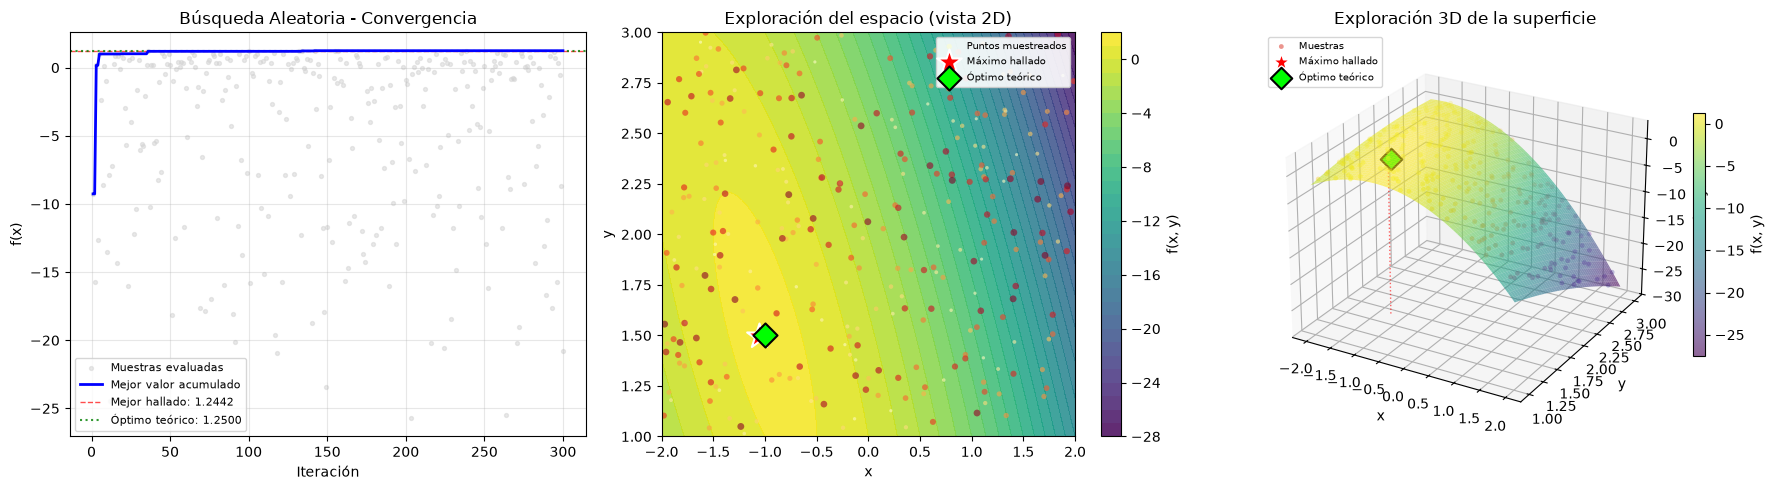

In [16]:
# Función del ejemplo del PDF: f(x,y) = y - x - 2x² - 2xy - y²
# Función del ejemplo: f(x,y) = y - x - 2x² - 2xy - y²
def f_busqueda(x, y):
    return y - x - 2*x**2 - 2*x*y - y**2

rangos = [(-2, 2), (1, 3)]
mejor_punto, mejor_valor, df_ba = busqueda_aleatoria(
    f_busqueda, rangos, n_iteraciones=300, semilla=42, modo="max"
)

print("Máximo encontrado en:")
print(f"   x = {mejor_punto[0]:.4f}")
print(f"   y = {mejor_punto[1]:.4f}")
print(f"   f(x,y) = {mejor_valor:.4f}")
print("\n(El máximo teórico es en x=-1, y=1.5 con f=1.25)")
print("\nTabla de iteraciones (primeras 10):")
display(df_ba.head(10))

# Ahora con el óptimo teórico (x=-1, y=1.5, f=1.25)
graficar_busqueda_aleatoria(
    f_busqueda, rangos, df_ba, mejor_punto, mejor_valor, 
    modo="max",
    optimo_teorico=(-1, 1.5),
    valor_teorico=1.25
)